In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [14]:
model = load_model("../model/cnn_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [15]:
dataset_path = os.path.join("..", "dataset")
test_path = os.path.join(dataset_path, "test")

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 624 images belonging to 2 classes.


# Evaluate Model

In [17]:
loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - accuracy: 0.8942 - loss: 0.2808
Test Loss     : 0.2808
Test Accuracy : 0.8942


In [18]:
predictions = model.predict(test_generator)

predicted_labels = (predictions > 0.5).astype(int).flatten()

true_labels = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 453ms/step


# Classification Report

In [19]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.90      0.80      0.85       234
   PNEUMONIA       0.89      0.95      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



# Confusion Matrix

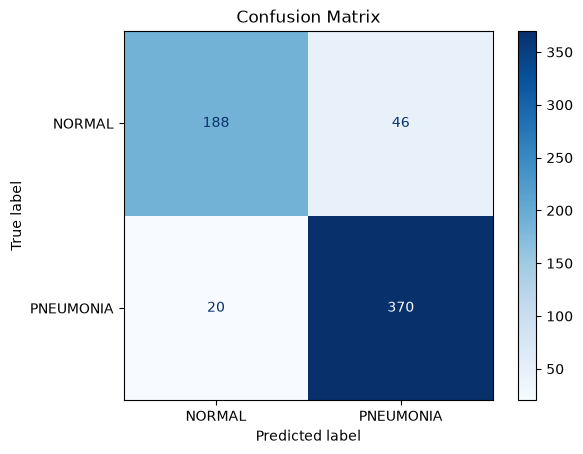

In [20]:
cm = confusion_matrix(true_labels, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL","PNEUMONIA"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# Test on One Image

In [21]:
image_path = "../dataset/test/NORMAL/IM-0001-0001.jpeg"

img = cv2.imread(image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img,(224,224))

img = img/255.0

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
    print("Confidence :", float(prediction[0][0]))
else:
    print("Prediction : NORMAL")
    print("Confidence :", float(1-prediction[0][0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
Prediction : NORMAL
Confidence : 0.8006066083908081


# Display the Test Image

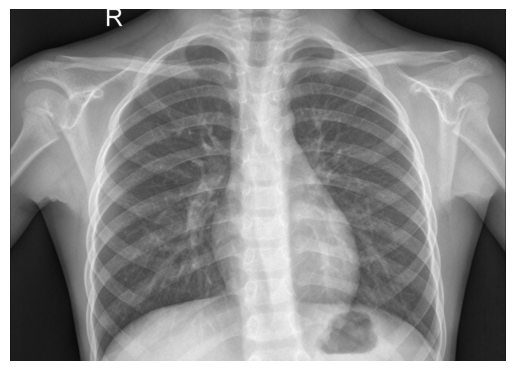

In [22]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
model.save("../model/cnn_model.keras")